In [1]:
# Configuração
from pathlib import Path
import os
import sys
import json
import time
import random

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/AMMCI_PRF")
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR = OUTPUT_DIR / "models"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto:", PROJECT_ROOT)
print("Dados:", DATA_DIR)

Projeto: D:\Workspace\ws-uem\acidentes-rodoviarios-ml
Dados: D:\Workspace\ws-uem\acidentes-rodoviarios-ml\data


# 04 — Seleção simples da MLP

## Objetivo

Selecionar a MLP usando somente D0.

D0 é dividido em 80% para treino e 20% para validação temporal.

Configurações comparadas:

- MLP sem pesos;
- MLP com balanceamento intermediário (`alpha = 0.5`);
- MLP com balanceamento completo;
- MLP combinada: `alpha = 0.5` + L2 + dropout.

`DummyClassifier` e regressão logística são baselines.

A seleção usa o **Macro-F1 médio** de três seeds e treino final de 10 épocas.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow import keras

TARGET = "classificacao_acidente"
SEEDS = [42, 123, 2026]
FINAL_EPOCHS = 10

CATEGORICAL_FEATURES = [
    "dia_semana", "uf", "br", "causa_acidente", "tipo_acidente",
    "fase_dia", "sentido_via", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo",
]

NUMERIC_FEATURES = [
    "hora", "mes", "km", "latitude", "longitude", "veiculos",
]

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

CLASS_NAMES = [
    "Sem Vítimas",
    "Com Vítimas Feridas",
    "Com Vítimas Fatais",
]

CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

BASE_CONFIG = {
    "hidden_units": [64, 32],
    "dropout": 0.0,
    "l2": 0.0,
    "learning_rate": 1e-3,
    "batch_size": 256,
    "epochs": 60,
    "class_weight_alpha": 0.0,
    "tracado_encoding": "multihot",
}

MLP_CONFIGS = [
    dict(
        BASE_CONFIG,
        name="Multi-hot — sem pesos",
    ),
    dict(
        BASE_CONFIG,
        name="Multi-hot — alpha 0.50",
        class_weight_alpha=0.50,
    ),
    dict(
        BASE_CONFIG,
        name="Multi-hot — balanceada",
        class_weight_alpha=1.0,
    ),
    dict(
        BASE_CONFIG,
        name="Multi-hot — combinada",
        hidden_units=[64],
        class_weight_alpha=0.50,
        l2=1e-4,
        dropout=0.10,
    ),
]

## 1. Dados e validação temporal

D0 é ordenado cronologicamente e dividido em treino e validação sem embaralhamento entre períodos.

In [3]:
# A seleção usa somente D0; D1 e D2 permanecem reservados.
D0_PATH = DATA_DIR / "d0.csv"

if not D0_PATH.exists():
    raise FileNotFoundError(
        f"Não encontrei {D0_PATH}. Execute primeiro o notebook 01."
    )

d0 = pd.read_csv(
    D0_PATH,
    sep=";",
    encoding="utf-8",
    dtype={"br": "string"},
    parse_dates=["timestamp"],
)

d0 = d0.sort_values("timestamp", kind="stable").reset_index(drop=True)

required = set(FEATURES + [TARGET, "timestamp"])
missing = required - set(d0.columns)

if missing:
    raise ValueError(f"Colunas ausentes: {sorted(missing)}")

cut = int(len(d0) * 0.80)
boundary = d0.iloc[cut]["timestamp"]

train_df = d0[d0["timestamp"] < boundary].copy()
val_df = d0[d0["timestamp"] >= boundary].copy()

assert train_df["timestamp"].max() < val_df["timestamp"].min()

print(f"D0: {len(d0):,}")
print(f"Treino: {len(train_df):,}")
print(f"Validação: {len(val_df):,}")
print("Fronteira:", boundary)

display(
    train_df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("%")
    .to_frame()
)

D0: 87,838
Treino: 70,270
Validação: 17,568
Fronteira: 2024-01-14 05:50:00


,%
classificacao_acidente,
Com Vítimas Feridas,76.69
Sem Vítimas,16.16
Com Vítimas Fatais,7.15


## 2. Pré-processamento, métricas e arquitetura

O pré-processamento é ajustado somente no treino interno e reutilizado na validação.

In [4]:
def build_preprocessor():
    categorical = [
        c for c in CATEGORICAL_FEATURES
        if c != "tracado_via"
    ]

    return ColumnTransformer(
        [
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=True,
                    )),
                ]),
                categorical,
            ),
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                NUMERIC_FEATURES,
            ),
            (
                "tracado",
                CountVectorizer(
                    token_pattern=r"(?u)[^;]+",
                    lowercase=False,
                    binary=True,
                    dtype=np.float32,
                ),
                "tracado_via",
            ),
        ],
        sparse_threshold=1.0,
    )


def dense(X):
    X = X.astype(np.float32)
    return X.toarray() if sparse.issparse(X) else np.asarray(X, dtype=np.float32)


def encode_y(df):
    return (
        df[TARGET]
        .map(CLASS_TO_ID)
        .to_numpy(dtype=np.int64)
    )


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def class_weights_for(y, alpha):
    if alpha == 0:
        return None

    counts = np.bincount(y, minlength=len(CLASS_NAMES))

    weights = (
        len(y) / (len(CLASS_NAMES) * counts)
    ) ** alpha

    weights /= np.average(
        weights,
        weights=counts,
    )

    return {
        i: float(weight)
        for i, weight in enumerate(weights)
    }


def build_mlp(input_dim, config, seed):
    set_seed(seed)

    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,))
    ])

    for units in config["hidden_units"]:
        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=keras.regularizers.l2(
                    config["l2"]
                ),
            )
        )

        if config["dropout"] > 0:
            model.add(
                keras.layers.Dropout(
                    config["dropout"]
                )
            )

    model.add(
        keras.layers.Dense(
            len(CLASS_NAMES),
            activation="softmax",
        )
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


class MacroF1Stopping(keras.callbacks.Callback):
    def __init__(self, X_val, y_val, patience=8):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.patience = patience

        self.best = -np.inf
        self.best_epoch = 0
        self.wait = 0
        self.best_weights = None
        self.scores = []

    def on_epoch_end(self, epoch, logs=None):
        pred = self.model.predict(
            self.X_val,
            batch_size=4096,
            verbose=0,
        ).argmax(axis=1)

        score = f1_score(
            self.y_val,
            pred,
            labels=range(len(CLASS_NAMES)),
            average="macro",
            zero_division=0,
        )

        self.scores.append(score)

        if score > self.best + 1e-4:
            self.best = score
            self.best_epoch = epoch + 1
            self.best_weights = self.model.get_weights()
            self.wait = 0
        else:
            self.wait += 1

            if self.wait >= self.patience:
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(
                self.best_weights
            )


def evaluate(name, y_true, proba, seconds, n_params=None):
    pred = proba.argmax(axis=1)

    return {
        "modelo": name,
        "accuracy": accuracy_score(y_true, pred),
        "macro_precision": precision_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "fatal_recall": recall_score(
            y_true,
            pred,
            labels=[2],
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_true, pred, average="macro", zero_division=0
        ),
        "mcc": matthews_corrcoef(y_true, pred),
        "macro_pr_auc": average_precision_score(
            np.eye(len(CLASS_NAMES))[y_true],
            proba,
            average="macro",
        ),
        "tempo_treino_s": seconds,
        "n_parametros": n_params,
    }

## 3. Baselines e configurações candidatas

As configurações candidatas são avaliadas sob a mesma fronteira temporal e o mesmo conjunto de métricas.

In [5]:
preprocessor = build_preprocessor()

X_train_sparse = preprocessor.fit_transform(
    train_df[FEATURES]
)

X_val_sparse = preprocessor.transform(
    val_df[FEATURES]
)

y_train = encode_y(train_df)
y_val = encode_y(val_df)

rows = []
histories = []
representative = {}

# --------------------------------------------------------
# Dummy
# --------------------------------------------------------
dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(
    X_train_sparse,
    y_train,
)

p = dummy.predict_proba(
    X_val_sparse
)

rows.append(
    evaluate(
        "Classe majoritária",
        y_val,
        p,
        0,
    )
)


# --------------------------------------------------------
# Regressão logística
# --------------------------------------------------------
logistic = LogisticRegression(
    class_weight=class_weights_for(y_train, 1.0),
    max_iter=1000,
    solver="lbfgs",
)

start = time.perf_counter()

logistic.fit(
    X_train_sparse,
    y_train,
)

seconds = time.perf_counter() - start

p = logistic.predict_proba(
    X_val_sparse
)

rows.append(
    evaluate(
        "Regressão logística",
        y_val,
        p,
        seconds,
    )
)


# --------------------------------------------------------
# MLP
# --------------------------------------------------------
X_train = dense(X_train_sparse)
X_val = dense(X_val_sparse)

for config in MLP_CONFIGS:
    for seed in SEEDS:

        keras.backend.clear_session()

        model = build_mlp(
            X_train.shape[1],
            config,
            seed,
        )

        stopper = MacroF1Stopping(
            X_val,
            y_val,
            patience=8,
        )

        start = time.perf_counter()

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            validation_batch_size=4096,
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            shuffle=True,
            verbose=0,
            class_weight=class_weights_for(
                y_train,
                config["class_weight_alpha"],
            ),
            callbacks=[stopper],
        )

        seconds = time.perf_counter() - start

        p = model.predict(
            X_val,
            batch_size=4096,
            verbose=0,
        )

        row = evaluate(
            config["name"],
            y_val,
            p,
            seconds,
            model.count_params(),
        )

        row.update({
            "seed": seed,
            "best_epoch": stopper.best_epoch,
            "class_weight_alpha": config["class_weight_alpha"],
            "hidden_units": str(config["hidden_units"]),
            "dropout": config["dropout"],
            "l2": config["l2"],
            "learning_rate": config["learning_rate"],
        })

        rows.append(row)

        for epoch, score in enumerate(
            stopper.scores,
            start=1,
        ):
            histories.append({
                "modelo": config["name"],
                "seed": seed,
                "epoch": epoch,
                "val_macro_f1": score,
            })

        if seed == 42:
            representative[
                config["name"]
            ] = p.copy()

        print(
            config["name"],
            "| seed",
            seed,
            "| Macro-F1:",
            round(row["macro_f1"], 4),
        )


runs = pd.DataFrame(rows)
history_df = pd.DataFrame(histories)

runs.to_csv(
    METRICS_DIR / "model_selection_runs.csv",
    index=False,
)

history_df.to_csv(
    METRICS_DIR / "model_selection_histories.csv",
    index=False,
)


Multi-hot — sem pesos | seed 42 | Macro-F1: 0.503
Multi-hot — sem pesos | seed 123 | Macro-F1: 0.4941
Multi-hot — sem pesos | seed 2026 | Macro-F1: 0.4917
Multi-hot — alpha 0.50 | seed 42 | Macro-F1: 0.5495
Multi-hot — alpha 0.50 | seed 123 | Macro-F1: 0.551
Multi-hot — alpha 0.50 | seed 2026 | Macro-F1: 0.548
Multi-hot — balanceada | seed 42 | Macro-F1: 0.4657
Multi-hot — balanceada | seed 123 | Macro-F1: 0.4755
Multi-hot — balanceada | seed 2026 | Macro-F1: 0.5098
Multi-hot — combinada | seed 42 | Macro-F1: 0.5576
Multi-hot — combinada | seed 123 | Macro-F1: 0.5597
Multi-hot — combinada | seed 2026 | Macro-F1: 0.555


## 4. Seleção por Macro-F1

A ordenação considera a média entre seeds, evitando selecionar uma configuração por uma única inicialização.

In [6]:
mlp_runs = runs[
    runs["seed"].notna()
].copy()

summary = (
    mlp_runs
    .groupby("modelo", as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        macro_precision=("macro_precision", "mean"),
        macro_recall=("macro_recall", "mean"),
        fatal_recall=("fatal_recall", "mean"),
        macro_f1=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        mcc=("mcc", "mean"),
        macro_pr_auc=("macro_pr_auc", "mean"),
        tempo_treino_s=("tempo_treino_s", "mean"),
    )
    .sort_values(
        ["macro_f1", "macro_f1_std"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(summary.round(4))

best_name = summary.iloc[0]["modelo"]

best_config = next(
    config
    for config in MLP_CONFIGS
    if config["name"] == best_name
)

print(
    "\nMLP selecionada:",
    best_name,
)

print(
    "Épocas do treino final:",
    FINAL_EPOCHS,
)

summary.to_csv(
    METRICS_DIR / "model_selection_mlp_configs.csv",
    index=False,
)


# Comparação simples entre famílias
references = runs[
    runs["seed"].isna()
][[
    "modelo",
    "accuracy",
    "macro_recall",
    "fatal_recall",
    "macro_f1",
    "mcc",
    "macro_pr_auc",
    "tempo_treino_s",
]]

winner = summary[
    summary["modelo"] == best_name
][[
    "modelo",
    "accuracy",
    "macro_recall",
    "fatal_recall",
    "macro_f1",
    "mcc",
    "macro_pr_auc",
    "tempo_treino_s",
]]

family_results = pd.concat(
    [references, winner],
    ignore_index=True,
)

print("\nComparação de referência:")
display(family_results.round(4))

family_results.to_csv(
    METRICS_DIR / "model_selection_families.csv",
    index=False,
)

,modelo,accuracy,macro_precision,macro_recall,fatal_recall,macro_f1,macro_f1_std,mcc,macro_pr_auc,tempo_treino_s
0,Multi-hot — combinada,0.7638,0.5756,0.5505,0.3962,0.5574,0.0024,0.3322,0.5716,21.1257
1,Multi-hot — alpha 0.50,0.7541,0.5624,0.5472,0.3887,0.5495,0.0015,0.3205,0.5654,14.9065
2,Multi-hot — sem pesos,0.7864,0.6167,0.4620,0.1648,0.4962,0.0060,0.2986,0.5504,25.8299
3,Multi-hot — balanceada,0.5961,0.4765,0.5963,0.6091,0.4837,0.0231,0.2777,0.5490,23.7327



MLP selecionada: Multi-hot — combinada
Épocas do treino final: 10

Comparação de referência:


,modelo,accuracy,macro_recall,fatal_recall,macro_f1,mcc,macro_pr_auc,tempo_treino_s
0,Classe majoritária,0.7710,0.3333,0.0000,0.2902,0.0000,0.3333,0.0000
1,Regressão logística,0.5818,0.6078,0.6487,0.4804,0.2806,0.5584,3.0633
2,Multi-hot — combinada,0.7638,0.5505,0.3962,0.5574,0.3322,0.5716,21.1257


## 5. Configuração selecionada

A matriz de confusão da seed 42 fornece uma visualização representativa; a seleção permanece baseada na média das três seeds.

                     precision    recall  f1-score   support

        Sem Vítimas     0.5047    0.4006    0.4466      2836
Com Vítimas Feridas     0.8377    0.8609    0.8491     13545
 Com Vítimas Fatais     0.3489    0.4103    0.3771      1187

           accuracy                         0.7561     17568
          macro avg     0.5637    0.5573    0.5576     17568
       weighted avg     0.7509    0.7561    0.7523     17568



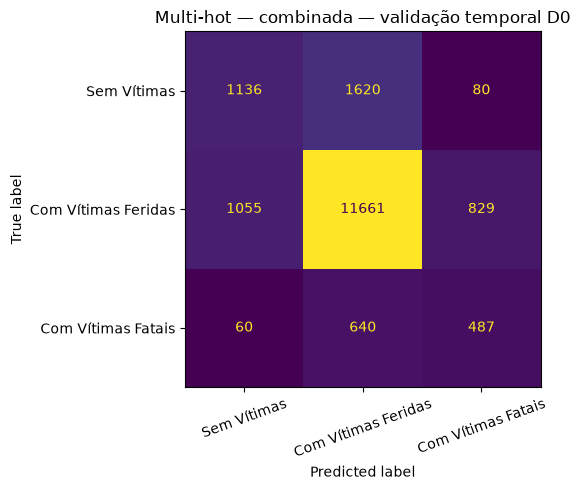

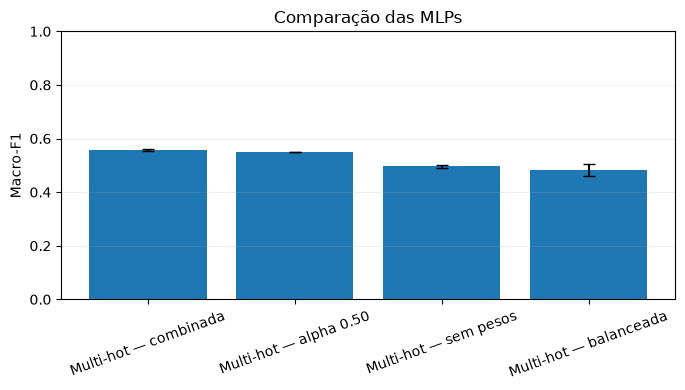

In [7]:
best_seed_42 = representative[best_name]
pred_seed_42 = best_seed_42.argmax(axis=1)

print(
    classification_report(
        y_val,
        pred_seed_42,
        labels=range(len(CLASS_NAMES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    pred_seed_42,
    display_labels=CLASS_NAMES,
    xticks_rotation=20,
    colorbar=False,
    ax=ax,
)

ax.set_title(
    f"{best_name} — validação temporal D0"
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(
    figsize=(7, 4)
)

ax.bar(
    summary["modelo"],
    summary["macro_f1"],
    yerr=summary["macro_f1_std"],
    capsize=4,
)

ax.set_ylabel("Macro-F1")
ax.set_title("Comparação das MLPs")
ax.set_ylim(0, 1)
ax.tick_params(
    axis="x",
    rotation=20,
)
ax.grid(
    axis="y",
    alpha=0.2,
)

plt.tight_layout()
plt.show()

## 6. Persistência da configuração

A configuração selecionada é persistida em JSON e utilizada pelo notebook 05 para reconstruir a MLP.

In [8]:
selection_config = {
    "selected_model": "MLP",
    "selected_config_name": best_name,
    "selection_metric": "macro_f1",
    "selection_seeds": SEEDS,
    "architecture": {
        "hidden_units": best_config["hidden_units"],
        "dropout": best_config["dropout"],
        "learning_rate": best_config["learning_rate"],
        "batch_size": best_config["batch_size"],
        "max_epochs": best_config["epochs"],
        "final_epochs": FINAL_EPOCHS,
        "class_weight_alpha": best_config["class_weight_alpha"],
        "l2": best_config["l2"],
    },
    "preprocessing": {
        "tracado_encoding": "multihot",
    },
    "target": TARGET,
    "class_names": CLASS_NAMES,
}

(MODEL_DIR / "mlp_config.json").write_text(
    json.dumps(
        selection_config,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

selected = summary.iloc[0]

print(
    f"Selecionada: {best_name}\n"
    f"Macro-F1: {selected['macro_f1']:.4f} "
    f"± {selected['macro_f1_std']:.4f}\n"
    f"Accuracy: {selected['accuracy']:.4f}\n"
    f"Recall fatal: {selected['fatal_recall']:.4f}\n"
    f"Épocas finais: {FINAL_EPOCHS}"
)

print("\nConfiguração salva. Próximo: notebook 05.")

Selecionada: Multi-hot — combinada
Macro-F1: 0.5574 ± 0.0024
Accuracy: 0.7638
Recall fatal: 0.3962
Épocas finais: 10

Configuração salva. Próximo: notebook 05.
